In [91]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import scipy.stats as stats
import numpy as np


## Задание 1

In [59]:

file_path = 'Задание 1.xlsx'  
subscribers_df = pd.read_excel(file_path, sheet_name='Абоненты')
charges_df = pd.read_excel(file_path, sheet_name='Начисления')
traffic_df = pd.read_excel(file_path, sheet_name='Трафики')

merged_df = pd.merge(subscribers_df, charges_df, on='Абонент')
merged_df = pd.merge(merged_df, traffic_df, on='Абонент')


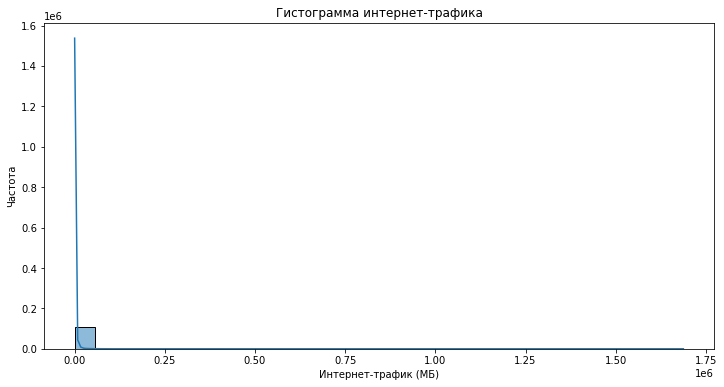

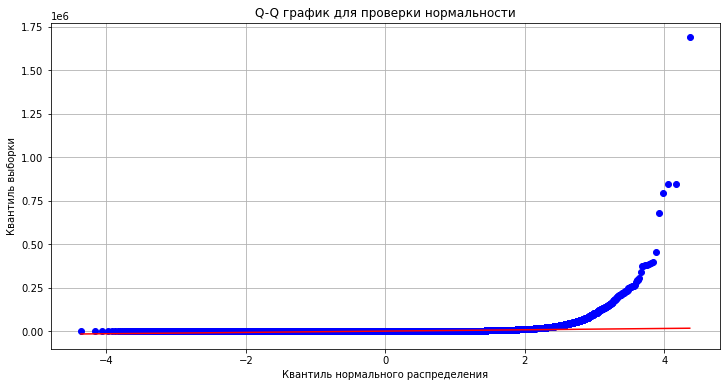

Статистика теста Шапиро-Уилка: 0.11786109209060669, p-значение: 0.0
Отвергаем нулевую гипотезу: распределение не нормально.


F:\anaconda\lib\site-packages\scipy\stats\morestats.py:1760: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [60]:

plt.figure(figsize=(12, 6))
sns.histplot(internet_traffic, bins=30, kde=True)
plt.title('Гистограмма интернет-трафика')
plt.xlabel('Интернет-трафик (МБ)')
plt.ylabel('Частота')
plt.show()

plt.figure(figsize=(12, 6))
stats.probplot(internet_traffic, dist="norm", plot=plt)
plt.title('Q-Q график для проверки нормальности')
plt.xlabel('Квантиль нормального распределения')
plt.ylabel('Квантиль выборки')
plt.grid()
plt.show()

shapiro_test = stats.shapiro(internet_traffic)
print(f"Статистика теста Шапиро-Уилка: {shapiro_test.statistic}, p-значение: {shapiro_test.pvalue}")

alpha = 0.05
if shapiro_test.pvalue > alpha:
    print("Нет оснований отвергать нулевую гипотезу: распределение нормально.")
else:
    print("Отвергаем нулевую гипотезу: распределение не нормально.")



*ввиду особенностей распределения для определения порога нам подойдет метод вычисления медианы и межквартильного размаха (IQR)*

In [61]:
internet_traffic = merged_df['Интернет-трафик, МБ']

median_traffic = internet_traffic.median()
q1 = internet_traffic.quantile(0.25)
q3 = internet_traffic.quantile(0.75)
iqr = q3 - q1

threshold = median_traffic + 1.5 * iqr
active_internet_users = merged_df[merged_df['Интернет-трафик, МБ'] > threshold]

significant_features = ['Тарифный план', 'Группа ТП', 'Регион', 'Пол', 'Дата рождения', 'Интернет-трафик, МБ']


In [77]:

profile = active_internet_users[significant_features]

def convert_date(date_str):
    date = pd.to_datetime(date_str, format='%d%b%y', errors='coerce')
    if date.year > datetime.now().year:
        date = date - pd.DateOffset(years=100)
    return date

profile['Дата рождения'] = profile['Дата рождения'].apply(convert_date)

current_date = datetime.now()
profile['Возраст'] = current_date.year - profile['Дата рождения'].dt.year


datetime_desc = profile.describe(include='datetime')
object_desc = profile.describe(include='object')
average_values = pd.concat([datetime_desc, object_desc], axis=1)
print("Профиль абонента, активно потребляющего интернет-трафик:")
print(profile)
print("\nСредние значения и частоты по характеристикам:")
print(average_values.iloc[2])


Профиль абонента, активно потребляющего интернет-трафик:
       Тарифный план  Группа ТП   Регион Пол Дата рождения  \
1               ТП 2          1    Минск   М    1987-11-24   
9               ТП 2          1    Брест   М    1989-06-01   
12              ТП 5          2    Минск   Ж    1968-01-28   
23              ТП 8          2    Минск   Ж    1985-12-06   
27              ТП 3          1    Минск   М    1969-07-10   
...              ...        ...      ...  ..           ...   
108353          ТП 1          1  Витебск   Ж    1978-05-02   
108354          ТП 1          1    Минск   М    1989-12-12   
108359          ТП 8          2    Минск   М    1968-12-15   
108360          ТП 2          1    Минск   Ж    1982-03-12   
108366          ТП 2          1    Минск   М    1986-09-28   

        Интернет-трафик, МБ  Возраст  
1               4544.004147     38.0  
9              10878.215660     36.0  
12              3785.757564     57.0  
23             10945.994491     40.0  
27 

C:\Users\Asus\AppData\Local\Temp\ipykernel_10500\3431936340.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile['Дата рождения'] = profile['Дата рождения'].apply(convert_date)
C:\Users\Asus\AppData\Local\Temp\ipykernel_10500\3431936340.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile['Возраст'] = current_date.year - profile['Дата рождения'].dt.year
C:\Users\Asus\AppData\Local\Temp\ipykernel_10500\3431936340.py:15: FutureWarning: Treating datetime data as categorical rather than numeric i

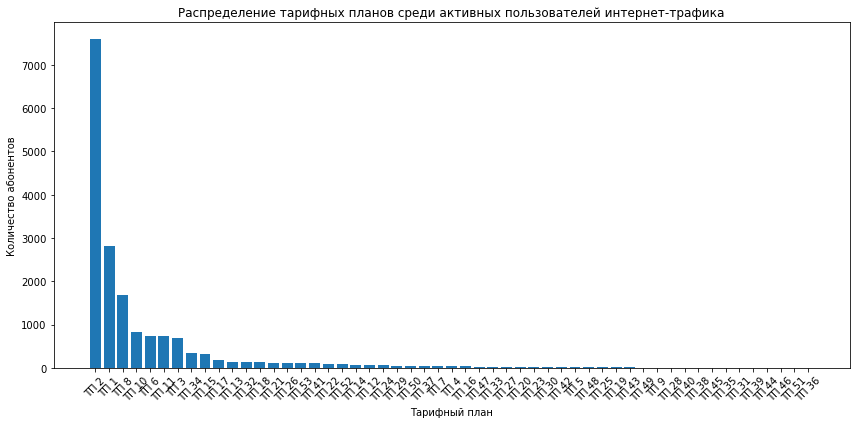

In [63]:


tariff_counts = profile['Тарифный план'].value_counts()
tariff_counts_df = tariff_counts.reset_index()
tariff_counts_df.columns = ['Тарифный план', 'Количество абонентов']

plt.figure(figsize=(12, 6))
plt.bar(tariff_counts_df['Тарифный план'], tariff_counts_df['Количество абонентов'])
plt.title('Распределение тарифных планов среди активных пользователей интернет-трафика')
plt.xlabel('Тарифный план')
plt.ylabel('Количество абонентов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



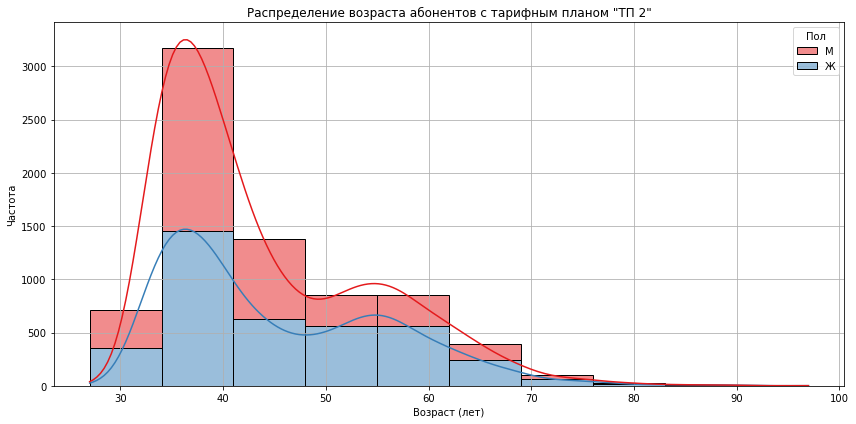

In [64]:

tp2_users = profile[profile['Тарифный план'] == 'ТП 2']

plt.figure(figsize=(12, 6))
sns.histplot(tp2_users, x='Возраст', hue='Пол', bins=10, kde=True, multiple='stack', palette='Set1')
plt.title('Распределение возраста абонентов с тарифным планом "ТП 2"')
plt.xlabel('Возраст (лет)')
plt.ylabel('Частота')
plt.grid()
plt.tight_layout()
plt.show()




**Таким образом средним определяем профиль абонента: Мужчина средних лет, проживающий в г.Минске с ТП2**

**Задание 2**

In [154]:
file_path = 'Задание 2.xlsx'  
df = pd.read_excel(file_path, sheet_name='Данные')

required_columns = ['id_campaign', 'cg_flag', 'target', 
                    'Начисления, M0', 'Начисления, M1', 'Начисления, M2',
                    'Начисления интернет, M0', 'Начисления интернет, M1', 'Начисления интернет, M2',
                    'Интернет трафик, МБ, M0', 'Интернет трафик, МБ, M1', 'Интернет трафик, МБ, M2']

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Отсутствует необходимый столбец: {col}")

results = []

for campaign in df['id_campaign'].unique():    
    for cg in [0, 1]:  
        campaign_data = df[(df['id_campaign'] == campaign) & (df['cg_flag'] == cg)]
        
        if campaign_data.empty:
            continue

        total_revenue_M0 = campaign_data['Начисления, M0'].sum()
        total_revenue_M1 = campaign_data['Начисления, M1'].sum()
        total_revenue_M2 = campaign_data['Начисления, M2'].sum()
        
        total_internet_revenue_M0 = campaign_data['Начисления интернет, M0'].sum()
        total_internet_revenue_M1 = campaign_data['Начисления интернет, M1'].sum()
        total_internet_revenue_M2 = campaign_data['Начисления интернет, M2'].sum()
        
        total_traffic_M0 = campaign_data['Интернет трафик, МБ, M0'].sum()
        total_traffic_M1 = campaign_data['Интернет трафик, МБ, M1'].sum()
        total_traffic_M2 = campaign_data['Интернет трафик, МБ, M2'].sum()
        
        results.append({
            'id_campaign': campaign,
            'cg_flag': cg,
            'total_revenue': [total_revenue_M0, total_revenue_M1, total_revenue_M2],
            'total_internet_revenue': [total_internet_revenue_M0, total_internet_revenue_M1, total_internet_revenue_M2],
            'total_traffic': [total_traffic_M0, total_traffic_M1, total_traffic_M2],
        })

results_df = pd.DataFrame(results)
results_df.to_excel('resulto2.xlsx')

In [156]:

def analyze_campaigns(df):
    results = []

    for campaign in df['id_campaign'].unique():    
        for cg in [0, 1]:  # 0 - не принадлежит, 1 - принадлежит к контрольной группе
            campaign_data = df[(df['id_campaign'] == campaign) & (df['cg_flag'] == cg)]
            
            if campaign_data.empty:
                continue

            total_participants = campaign_data['target'].sum()
            total_abonents = len(campaign_data)
            participation_rate = (total_participants / total_abonents) * 100
            
            total_revenue_M0 = campaign_data['Начисления, M0'].sum()
            total_revenue_M1 = campaign_data['Начисления, M1'].sum()
            total_revenue_M2 = campaign_data['Начисления, M2'].sum()
            
            total_internet_revenue_M0 = campaign_data['Начисления интернет, M0'].sum()
            total_internet_revenue_M1 = campaign_data['Начисления интернет, M1'].sum()
            total_internet_revenue_M2 = campaign_data['Начисления интернет, M2'].sum()
            
            total_traffic_M0 = campaign_data['Интернет трафик, МБ, M0'].sum()
            total_traffic_M1 = campaign_data['Интернет трафик, МБ, M1'].sum()
            total_traffic_M2 = campaign_data['Интернет трафик, МБ, M2'].sum()
            
            results.append({
                'id_campaign': campaign,
                'cg_flag': cg,
                'participation_rate': participation_rate,
                'total_revenue_M0': total_revenue_M0,
                'total_revenue_M1': total_revenue_M1,
                'total_revenue_M2': total_revenue_M2,
                'total_internet_revenue_M0': total_internet_revenue_M0,
                'total_internet_revenue_M1': total_internet_revenue_M1,
                'total_internet_revenue_M2': total_internet_revenue_M2,
                'total_traffic_M0': total_traffic_M0,
                'total_traffic_M1': total_traffic_M1,
                'total_traffic_M2': total_traffic_M2,
            })
    
    return pd.DataFrame(results)

campaign_results = analyze_campaigns(df)

print(campaign_results)


  id_campaign  cg_flag  participation_rate  total_revenue_M0  \
0  Кампания 1        0            8.098592      47875.780255   
1  Кампания 1        1            4.932432       8367.006700   
2  Кампания 2        0            7.532727      49732.371729   
3  Кампания 2        1            4.868154       5360.747997   

   total_revenue_M1  total_revenue_M2  total_internet_revenue_M0  \
0      59376.939982      63241.047532                4827.066984   
1      10139.037427      10772.524690                 853.414394   
2      58752.718580      57694.354795                6951.530996   
3       6781.766112       6570.101074                 728.666530   

   total_internet_revenue_M1  total_internet_revenue_M2  total_traffic_M0  \
0                7656.310015                8390.629448      7.938561e+06   
1                1335.068327                1331.278552      9.090935e+05   
2                8721.013980                9338.587495      7.904450e+06   
3                 990.200712  

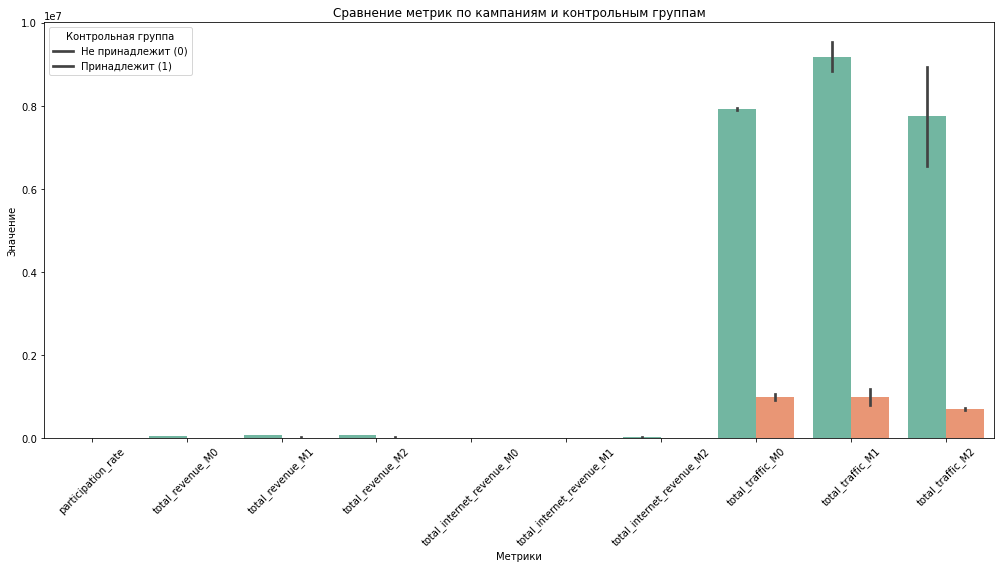

In [114]:

metrics = ['participation_rate', 
           'total_revenue_M0', 
           'total_revenue_M1', 
           'total_revenue_M2', 
           'total_internet_revenue_M0',
           'total_internet_revenue_M1', 
           'total_internet_revenue_M2', 
           'total_traffic_M0', 
           'total_traffic_M1', 
           'total_traffic_M2']


# Создание DataFrame для визуализации
melted_data = campaign_results.melt(id_vars=['id_campaign', 'cg_flag'], 
                                     value_vars=metrics, 
                                     var_name='metric', 
                                     value_name='value')

# Построение графика
plt.figure(figsize=(14, 8))
sns.barplot(data=melted_data, x='metric', y='value', hue='cg_flag', 
            ci='sd', palette='Set2', dodge=True)

# Настройка графика
plt.title('Сравнение метрик по кампаниям и контрольным группам')
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.xticks(rotation=45)
plt.legend(title='Контрольная группа', labels=['Не принадлежит (0)', 'Принадлежит (1)'])
plt.tight_layout()
plt.show()


<h3>     задание 4 

```
SELECT 
    region_id,
    region_name,
    top_tariff_plan,
    SUM(price * users_amount) AS Выручка
FROM 
    table
WHERE 
    top_tariff_plan <> 'Супер Голос'
GROUP BY 
    region_id, region_name, top_tariff_plan
HAVING 
    SUM(price * users_amount) > 4500000
ORDER BY 
    Выручка DESC;```